# Lab 1 · Task 1 · Variant 3 — Cars93

**Dataset:** 93 car models from the 1993 model year (Lock, 1993 / Consumer Reports)  
**Variable of interest:** Horsepower

The goal is to explore how horsepower is distributed across the full sample and broken down by car type — using summary statistics and three types of plots: ECDF, histogram, and box-plot.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
})

df = pd.read_csv("../data/cars93.csv")
print(df[["Type", "Horsepower"]].info())
print(df["Horsepower"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Type        93 non-null     object
 1   Horsepower  93 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB
None
count     93.000000
mean     143.827957
std       52.374410
min       55.000000
25%      103.000000
50%      140.000000
75%      170.000000
max      300.000000
Name: Horsepower, dtype: float64


## 1. Car Type Distribution

Type
Midsize    22
Small      21
Compact    16
Sporty     14
Large      11
Van         9

Most common:  Midsize (22)
Least common: Van (9)


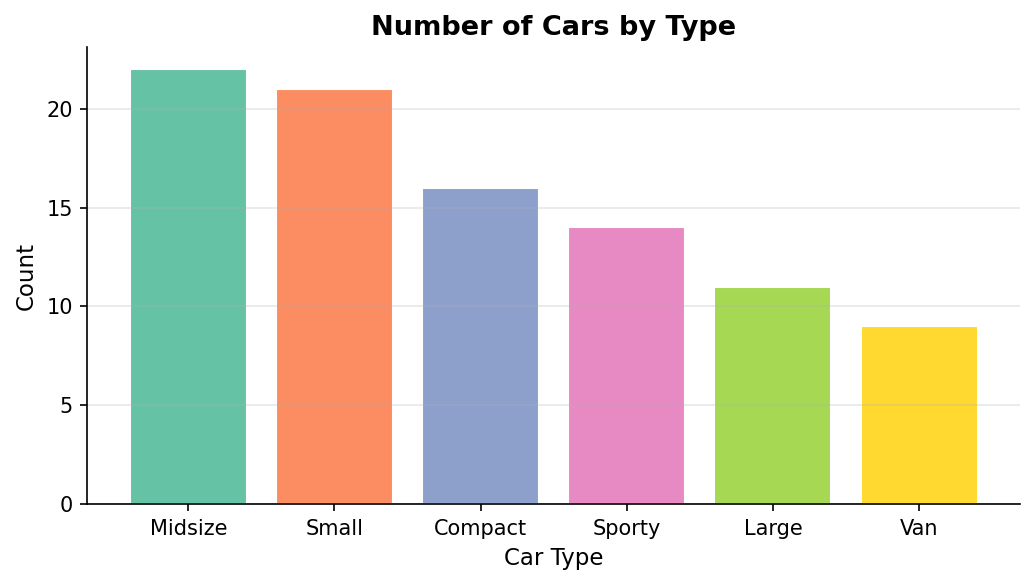

In [12]:
type_counts = df["Type"].value_counts()
print(type_counts.to_string())
print(f"\nMost common:  {type_counts.idxmax()} ({type_counts.max()})")
print(f"Least common: {type_counts.idxmin()} ({type_counts.min()})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(type_counts.index, type_counts.values,
       color=sns.color_palette("Set2", len(type_counts)), edgecolor="white")
ax.set_xlabel("Car Type")
ax.set_ylabel("Count")
ax.set_title("Number of Cars by Type")
ax.yaxis.grid(True)
plt.tight_layout()
plt.savefig("../results/figures/type_distribution.png")
plt.show()

## 2. Descriptive Statistics — Horsepower

Sample statistics computed for the full dataset and broken down by car type.  
Variance uses **ddof=1** (unbiased sample estimator). IQR = Q3 − Q1.

In [16]:
def describe_hp(data, label="Overall"):
    return {
        "Group":    label,
        "N":        len(data),
        "Mean":     round(data.mean(), 2),
        "Variance": round(data.var(ddof=1), 2),
        "Median":   round(data.median(), 2),
        "IQR":      round(data.quantile(0.75) - data.quantile(0.25), 2),
    }

hp = df["Horsepower"].dropna()
rows = [describe_hp(hp, "Overall")]
for t in sorted(df["Type"].unique()):
    rows.append(describe_hp(df.loc[df["Type"] == t, "Horsepower"].dropna(), t))

stats_df = pd.DataFrame(rows).set_index("Group")
print(stats_df.to_string())

          N    Mean  Variance  Median    IQR
Group                                       
Overall  93  143.83   2743.08   140.0  67.00
Compact  16  131.00    518.53   132.0  33.25
Large    11  179.45    477.07   170.0  25.00
Midsize  22  173.09   2756.09   169.0  69.00
Small    21   91.00    447.60    90.0  21.00
Sporty   14  160.14   5536.29   147.5  72.25
Van       9  149.44    370.28   151.0  23.00


## 3. Visualizations

### 3.1 Overall Distribution
ECDF, histogram, and box-plot for the full sample.

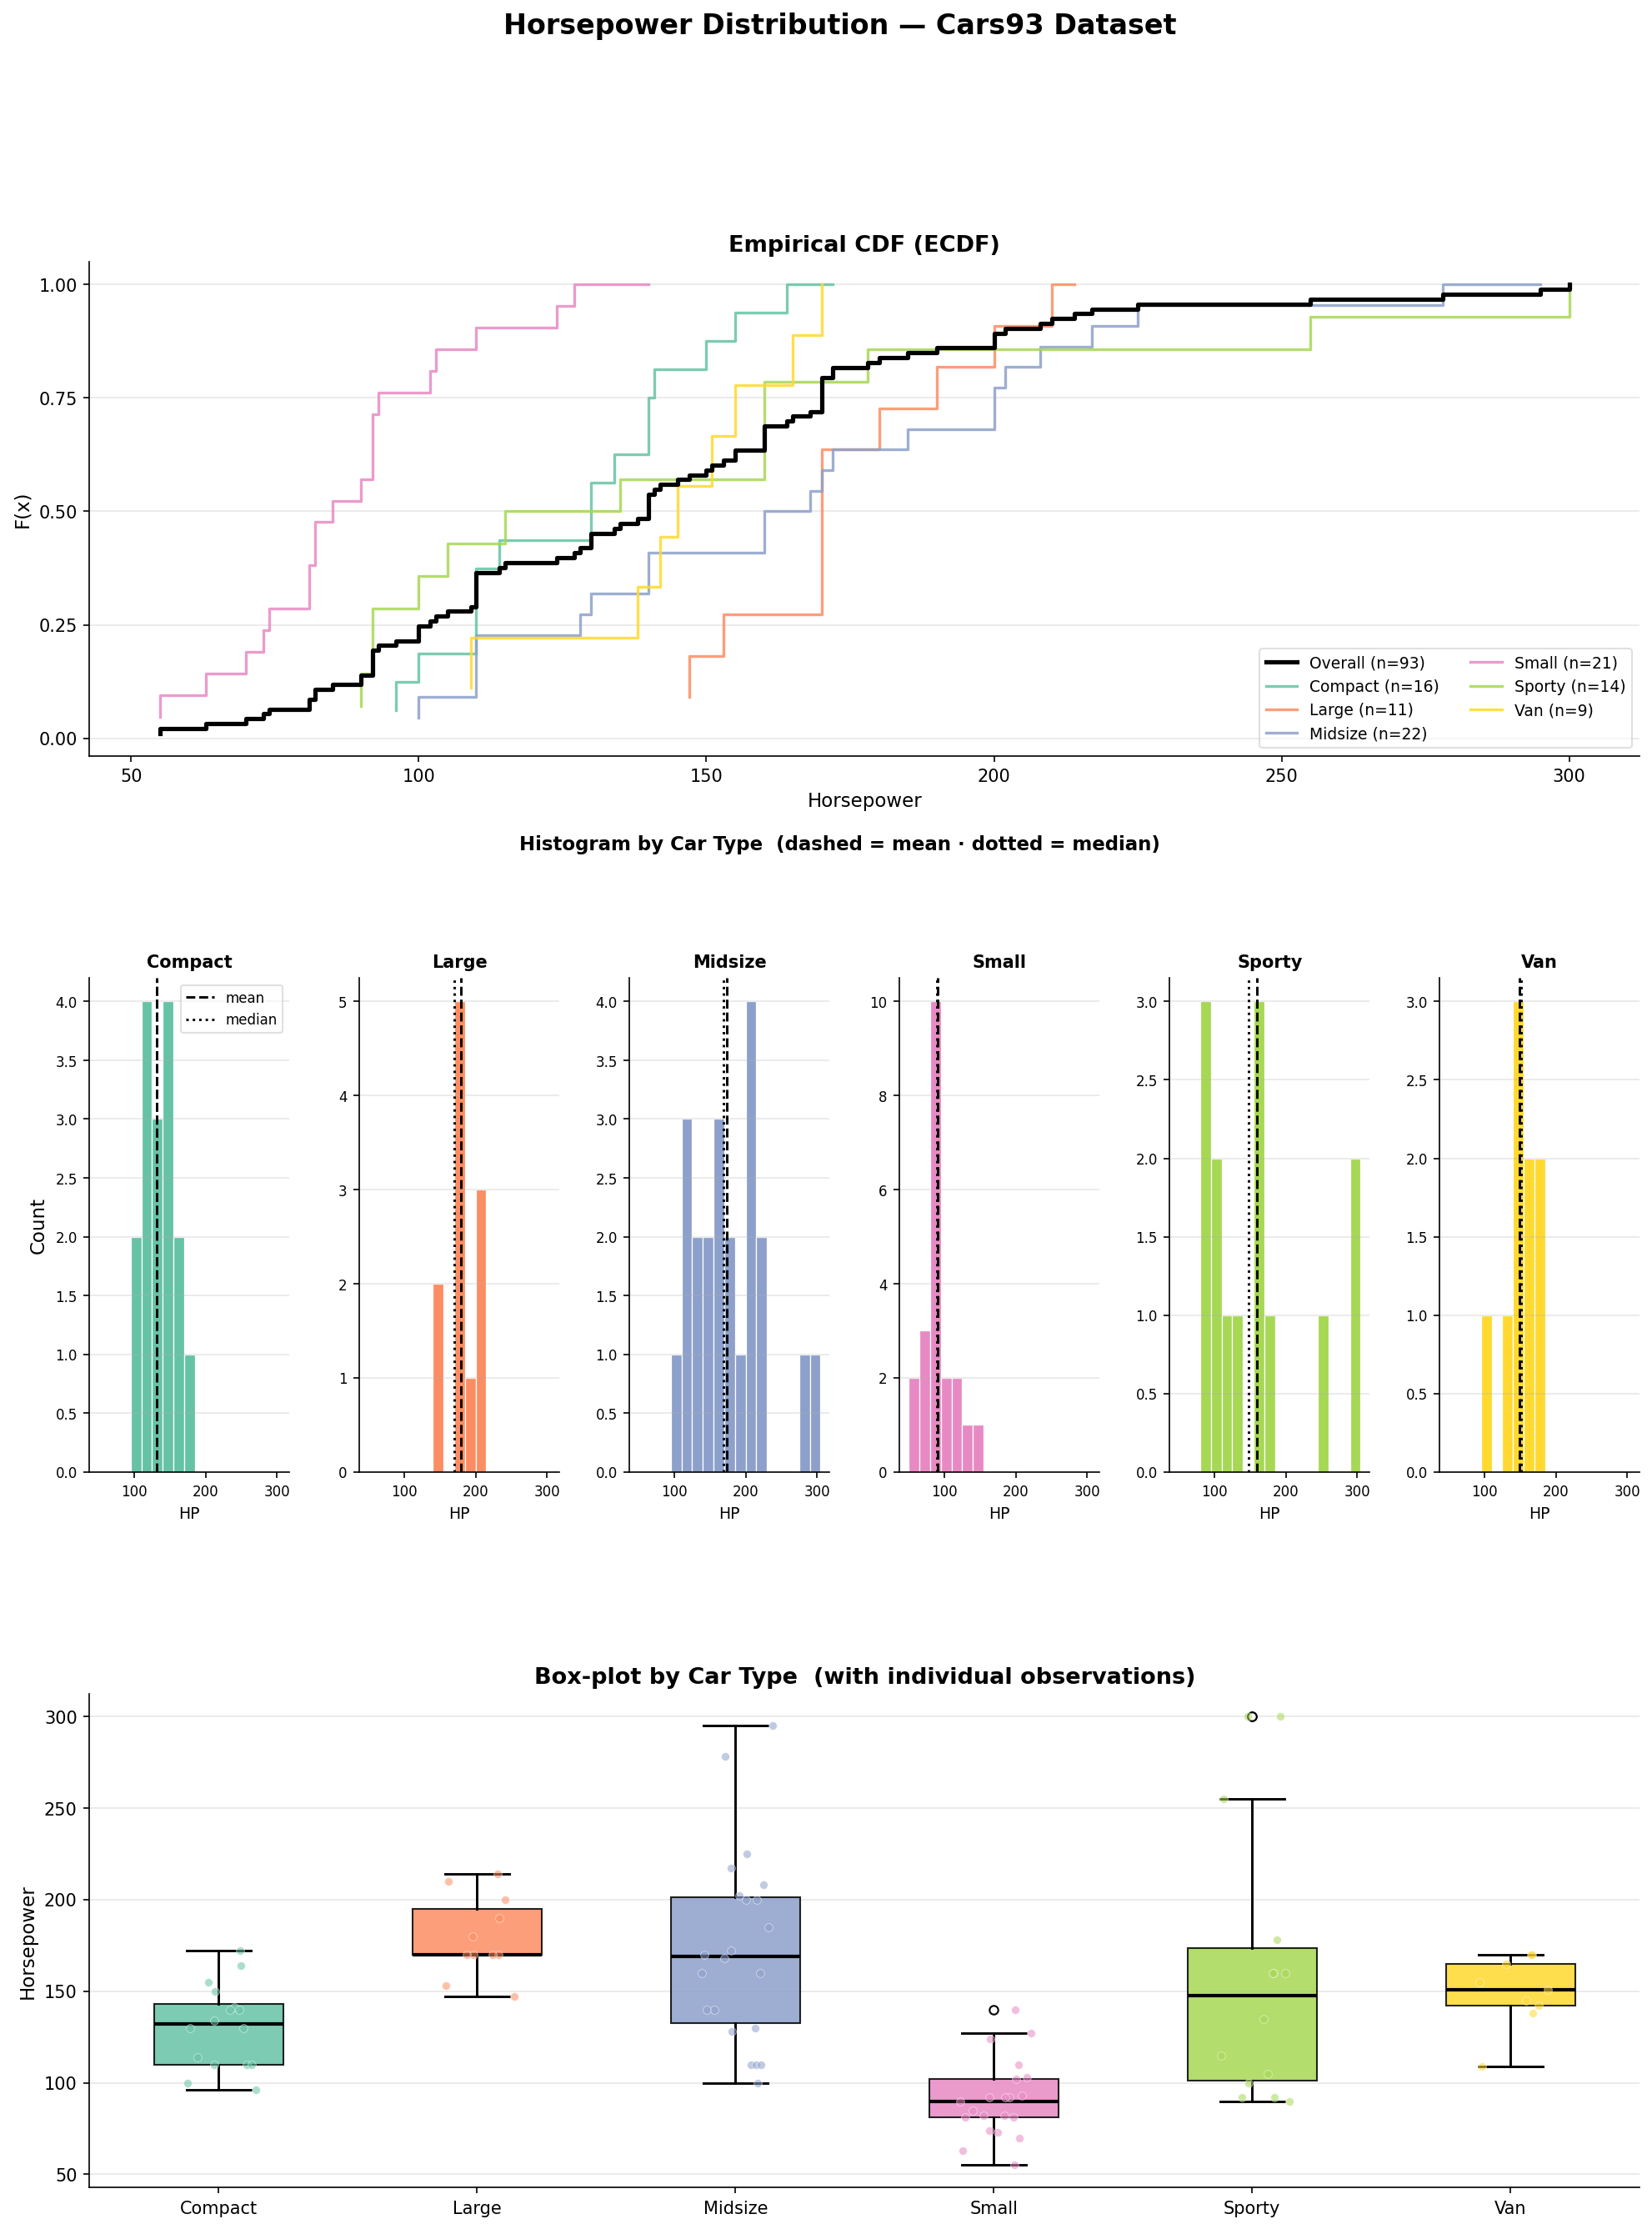

Figure saved to results/figures/


In [17]:
types   = sorted(df["Type"].unique())
palette = dict(zip(types, sns.color_palette(PALETTE, len(types))))
n_types = len(types)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
fig.suptitle("Horsepower Distribution — Cars93 Dataset", fontsize=16,
             fontweight="bold", y=0.98)

gs = fig.add_gridspec(3, 1, hspace=0.45)

# ── 1. ECDF ──────────────────────────────────────────────────────────────────
ax_ecdf = fig.add_subplot(gs[0])

# Overall ECDF (thick black)
x_all = np.sort(hp.values)
y_all = np.arange(1, len(x_all)+1) / len(x_all)
ax_ecdf.step(x_all, y_all, color="black", lw=2.5, label=f"Overall (n={len(x_all)})", zorder=5)

# Per-type ECDFs
for t in types:
    x = np.sort(df.loc[df["Type"]==t, "Horsepower"].dropna().values)
    y = np.arange(1, len(x)+1) / len(x)
    ax_ecdf.step(x, y, color=palette[t], lw=1.6, alpha=0.85,
                 label=f"{t} (n={len(x)})")

ax_ecdf.set_title("Empirical CDF (ECDF)")
ax_ecdf.set_xlabel("Horsepower")
ax_ecdf.set_ylabel("F(x)")
ax_ecdf.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax_ecdf.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{v:.2f}"))
ax_ecdf.grid(axis="y")
ax_ecdf.legend(fontsize=9, ncol=2, framealpha=0.6)

# ── 2. Histogram — separate panel per type ──────────────────────────────────
gs_hist = gs[1].subgridspec(1, n_types, wspace=0.35)
axes_h  = [fig.add_subplot(gs_hist[0, i]) for i in range(n_types)]

# Shared bins across all types for comparability
bins = np.linspace(hp.min() - 5, hp.max() + 5, 18)

for i, (t, ax) in enumerate(zip(types, axes_h)):
    data = df.loc[df["Type"]==t, "Horsepower"].dropna()
    ax.hist(data, bins=bins, color=palette[t], edgecolor="white", linewidth=0.6)
    ax.axvline(data.mean(),   color="black", lw=1.4, ls="--", label="mean")
    ax.axvline(data.median(), color="black", lw=1.4, ls=":",  label="median")
    ax.set_title(t, fontsize=10)
    ax.set_xlabel("HP", fontsize=9)
    if i == 0:
        ax.set_ylabel("Count")
    ax.tick_params(labelsize=8)
    ax.grid(axis="y")
    if i == 0:
        ax.legend(fontsize=8, framealpha=0.6)

# Shared super-title for histogram row
fig.text(0.5, 0.645, "Histogram by Car Type  (dashed = mean · dotted = median)",
         ha="center", fontsize=11, fontweight="bold")

# ── 3. Box-plot ──────────────────────────────────────────────────────────────
ax_box = fig.add_subplot(gs[2])

bp_data = [df.loc[df["Type"]==t, "Horsepower"].dropna().values for t in types]

bp = ax_box.boxplot(bp_data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.4),
                    capprops=dict(lw=1.4),
                    flierprops=dict(marker="o", markersize=5,
                                   markerfacecolor="white", markeredgewidth=1))
for patch, t in zip(bp["boxes"], types):
    patch.set_facecolor(palette[t])
    patch.set_alpha(0.85)

# Overlay individual data points (jittered)
for i, (t, data) in enumerate(zip(types, bp_data), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(data))
    ax_box.scatter(i + jitter, data, color=palette[t],
                   s=22, alpha=0.55, zorder=3, edgecolors="white", linewidths=0.4)

ax_box.set_xticks(range(1, n_types+1))
ax_box.set_xticklabels(types, fontsize=10)
ax_box.set_title("Box-plot by Car Type  (with individual observations)")
ax_box.set_ylabel("Horsepower")
ax_box.grid(axis="y")

plt.savefig("../results/figures/task1_horsepower.png",
            bbox_inches="tight", dpi=180)
plt.show()
print("Figure saved to results/figures/")

### 3.2 Distribution by Car Type
The same three plots broken down by the six car types.

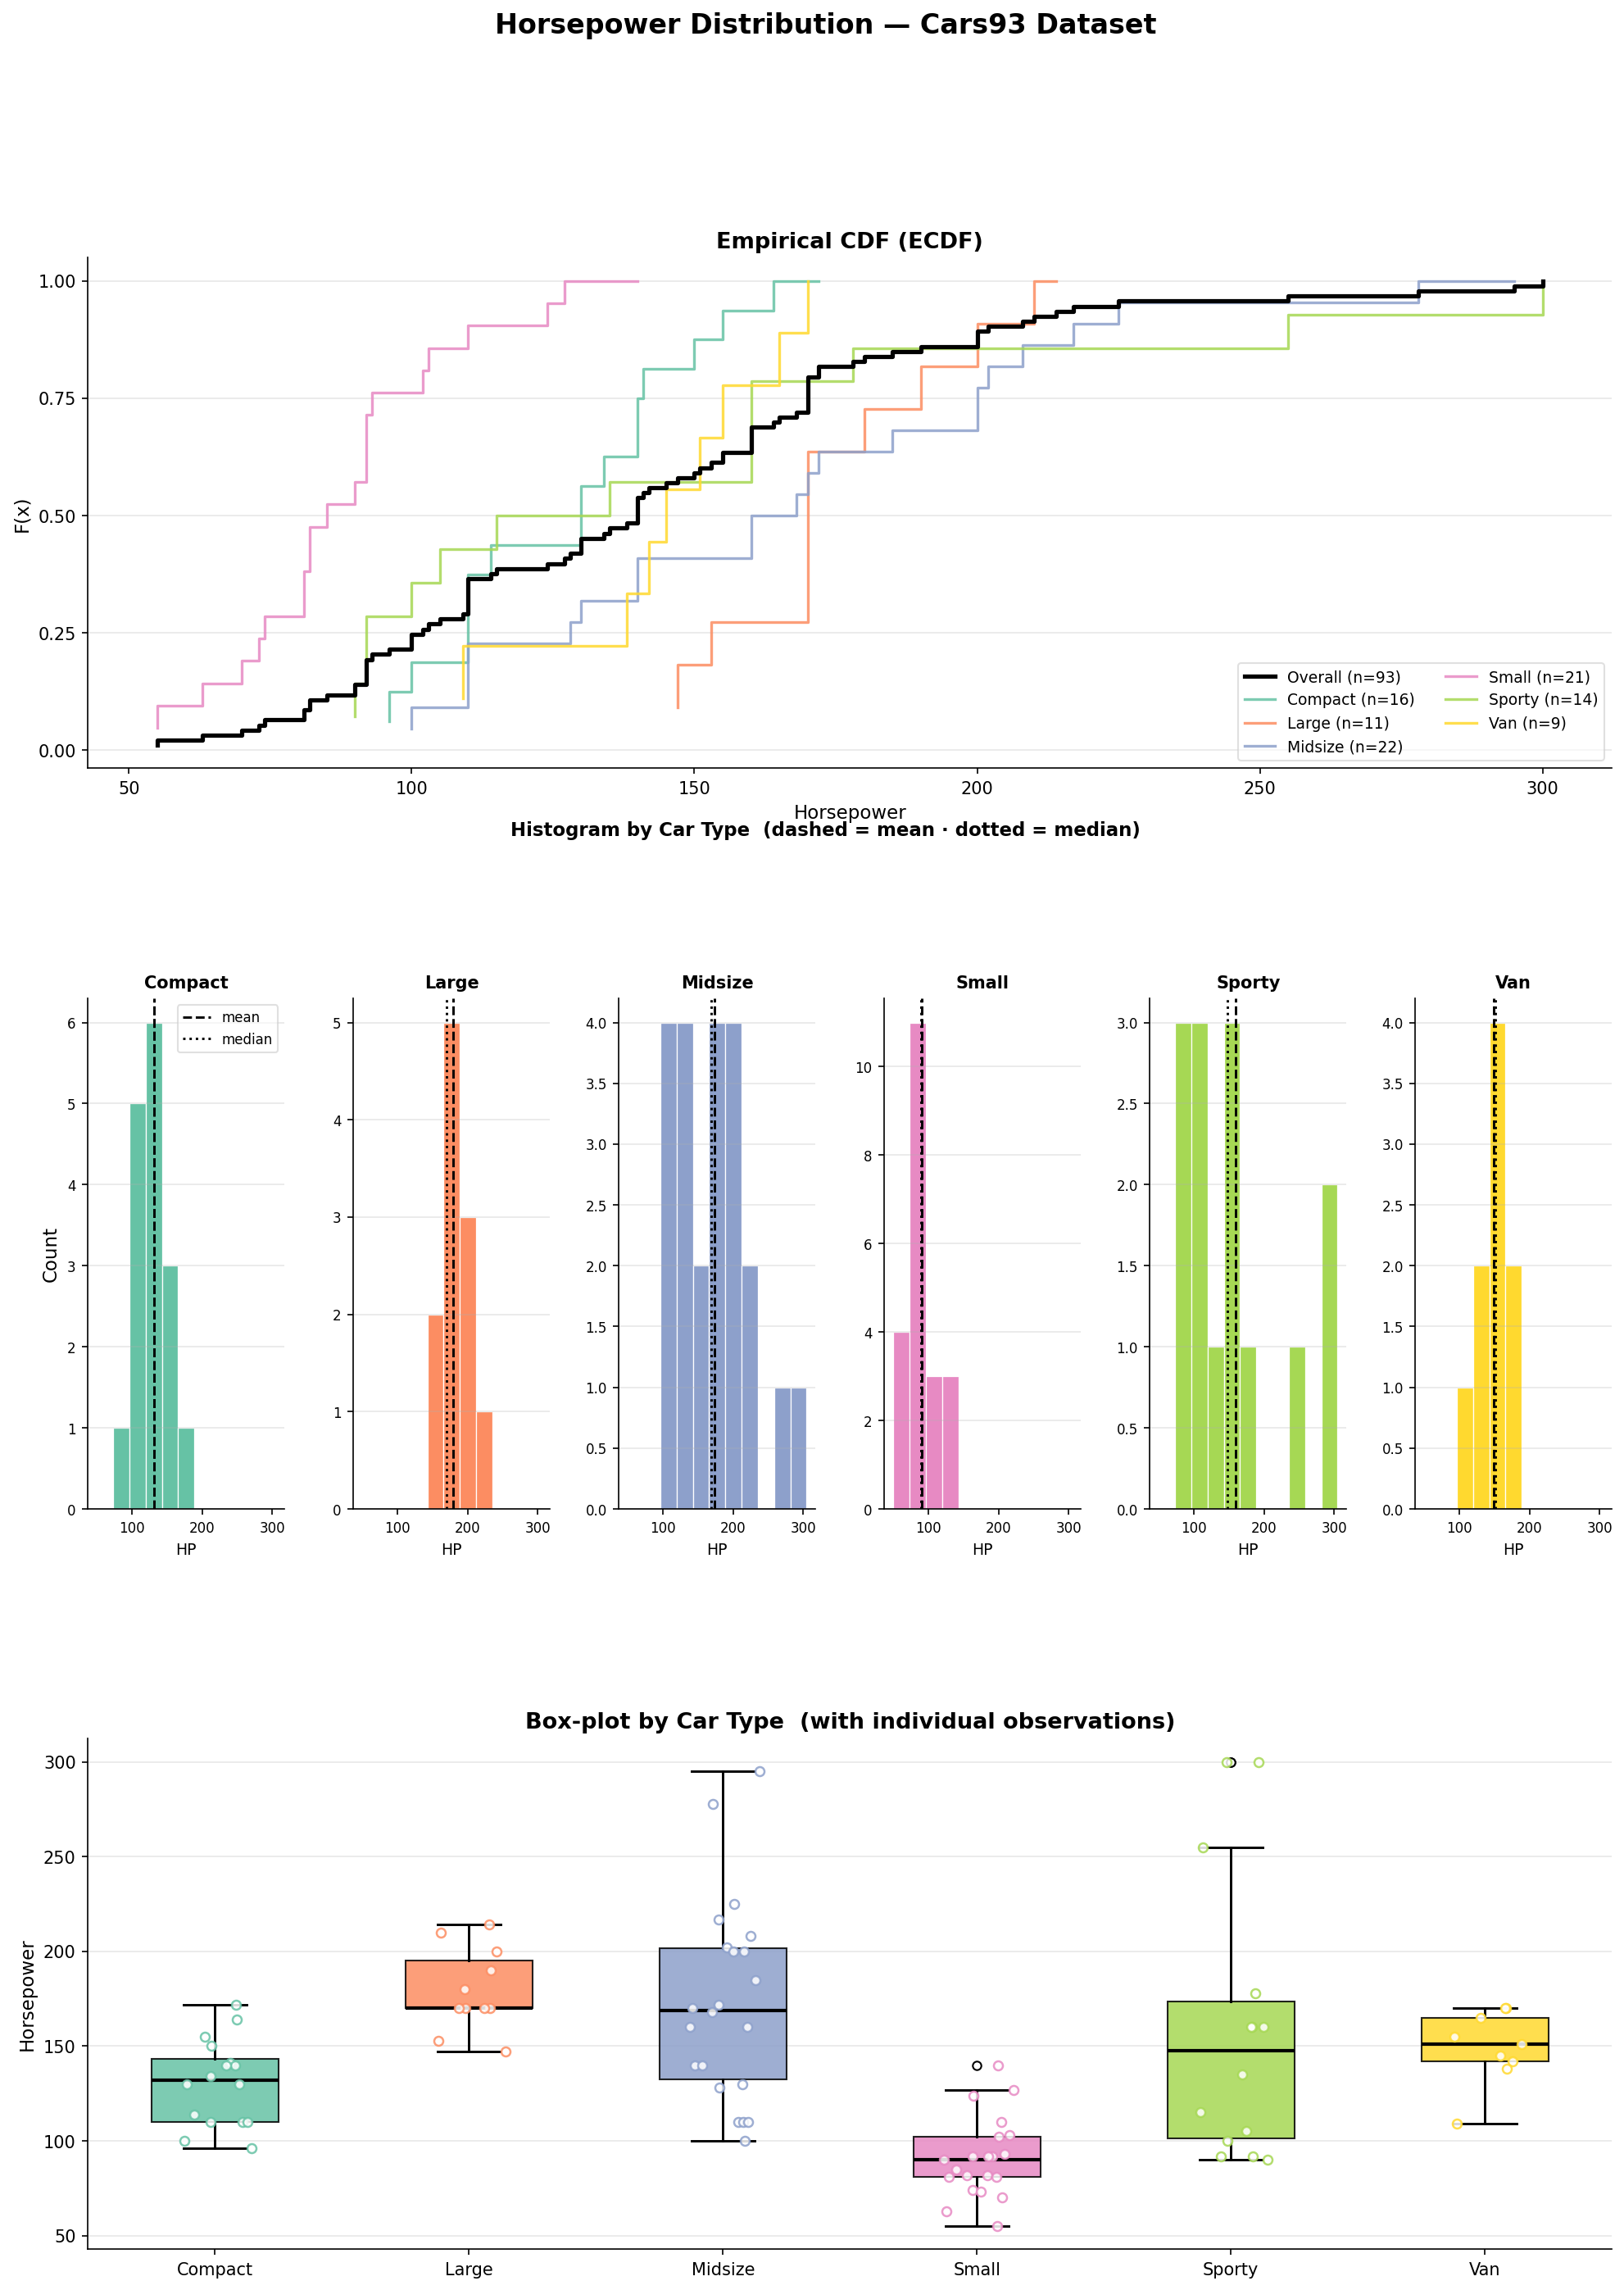

Figure saved to results/figures/


In [23]:
types   = sorted(df["Type"].unique())
palette = dict(zip(types, sns.color_palette(PALETTE, len(types))))
n_types = len(types)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
fig.suptitle("Horsepower Distribution — Cars93 Dataset", fontsize=16,
             fontweight="bold", y=0.98)

gs = fig.add_gridspec(3, 1, hspace=0.45)

# ── 1. ECDF ──────────────────────────────────────────────────────────────────
ax_ecdf = fig.add_subplot(gs[0])

# Overall ECDF (thick black)
x_all = np.sort(hp.values)
y_all = np.arange(1, len(x_all)+1) / len(x_all)
ax_ecdf.step(x_all, y_all, color="black", lw=2.5, label=f"Overall (n={len(x_all)})", zorder=5)

# Per-type ECDFs
for t in types:
    x = np.sort(df.loc[df["Type"]==t, "Horsepower"].dropna().values)
    y = np.arange(1, len(x)+1) / len(x)
    ax_ecdf.step(x, y, color=palette[t], lw=1.6, alpha=0.85,
                 label=f"{t} (n={len(x)})")

ax_ecdf.set_title("Empirical CDF (ECDF)")
ax_ecdf.set_xlabel("Horsepower")
ax_ecdf.set_ylabel("F(x)")
ax_ecdf.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax_ecdf.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{v:.2f}"))
ax_ecdf.grid(axis="y")
ax_ecdf.legend(fontsize=9, ncol=2, framealpha=0.6)

# ── 2. Histogram — separate panel per type ──────────────────────────────────
gs_hist = gs[1].subgridspec(1, n_types, wspace=0.35)
axes_h  = [fig.add_subplot(gs_hist[0, i]) for i in range(n_types)]

# Shared bins across all types for comparability
bins = np.linspace(hp.min() - 5, hp.max() + 5, 12)

for i, (t, ax) in enumerate(zip(types, axes_h)):
    data = df.loc[df["Type"]==t, "Horsepower"].dropna()
    ax.hist(data, bins=bins, color=palette[t], edgecolor="white", linewidth=0.6)
    ax.axvline(data.mean(),   color="black", lw=1.4, ls="--", label="mean")
    ax.axvline(data.median(), color="black", lw=1.4, ls=":",  label="median")
    ax.set_title(t, fontsize=10)
    ax.set_xlabel("HP", fontsize=9)
    if i == 0:
        ax.set_ylabel("Count")
    ax.tick_params(labelsize=8)
    ax.grid(axis="y")
    if i == 0:
        ax.legend(fontsize=8, framealpha=0.6)

# Shared super-title for histogram row
fig.text(0.5, 0.645, "Histogram by Car Type  (dashed = mean · dotted = median)",
         ha="center", fontsize=11, fontweight="bold")

# ── 3. Box-plot ──────────────────────────────────────────────────────────────
ax_box = fig.add_subplot(gs[2])

bp_data = [df.loc[df["Type"]==t, "Horsepower"].dropna().values for t in types]

bp = ax_box.boxplot(bp_data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.4),
                    capprops=dict(lw=1.4),
                    flierprops=dict(marker="o", markersize=5,
                                   markerfacecolor="white", markeredgewidth=1))
for patch, t in zip(bp["boxes"], types):
    patch.set_facecolor(palette[t])
    patch.set_alpha(0.85)

# Overlay individual data points (jittered)
for i, (t, data) in enumerate(zip(types, bp_data), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(data))
    ax_box.scatter(i + jitter, data, color="white",
               s=28, alpha=0.85, zorder=3,
               edgecolors=palette[t], linewidths=1.2)
    
ax_box.set_xticks(range(1, n_types+1))
ax_box.set_xticklabels(types, fontsize=10)
ax_box.set_title("Box-plot by Car Type  (with individual observations)")
ax_box.set_ylabel("Horsepower")
ax_box.grid(axis="y")

fig.subplots_adjust(bottom=0.07)
plt.savefig("../results/figures/task1_horsepower.png",
            bbox_inches="tight", dpi=180)
plt.show()
print("Figure saved to results/figures/")

## 4. Summary of Findings

| Statistic | Value |
|-----------|-------|
| Most common type | Midsize (22 cars) |
| Least common type | Van (9 cars) |

Key observations from the distributions:
- **Small** cars cluster tightly at low horsepower (~90–110 HP) with minimal spread
- **Sporty** cars show the widest range, extending up to 300 HP
- **Large** and **Midsize** cars overlap heavily in the 140–200 HP range
- The overall ECDF shows a roughly symmetric distribution centered near 150 HP

In [24]:
print("=" * 62)
print(f"{'Horsepower Statistics':^62}")
print("=" * 62)
print(stats_df.to_string())
print("=" * 62)
print("\nNotes:")
print("  · Variance: unbiased estimator (ddof=1)")
print("  · IQR = Q3 − Q1 (spread of the middle 50% of the data)")

                    Horsepower Statistics                     
          N    Mean  Variance  Median    IQR
Group                                       
Overall  93  143.83   2743.08   140.0  67.00
Compact  16  131.00    518.53   132.0  33.25
Large    11  179.45    477.07   170.0  25.00
Midsize  22  173.09   2756.09   169.0  69.00
Small    21   91.00    447.60    90.0  21.00
Sporty   14  160.14   5536.29   147.5  72.25
Van       9  149.44    370.28   151.0  23.00

Notes:
  · Variance: unbiased estimator (ddof=1)
  · IQR = Q3 − Q1 (spread of the middle 50% of the data)
